# Lecture 1: Probabilities

## Contents
- [1.1 Why statistics exists](#section-11)
  Scientific questions, measurement, and the limits of data
- [1.2 What is statistics](#section-12)
  Reasoning about reality using data and models
- [1.3 What is data](#section-13)
  Measurements, observations, and scientific evidence
- [1.4 Imperfect data](#section-14)
  Noise, bias, and uncertainty in measurement
- [1.5 Types of data](#section-15)
  How measurements are represented and analyzed
- [1.6 Probability and uncertainty](#section-16)
  Quantifying uncertainty about unknown quantities
- [1.7 Probability distributions](#section-17)
  Parameterized probability distributions express multiple possibilities
- [1.8 Parameters and describing distributions](#section-18)
  Summarizing the world
- [1.9 About this course](#section-19)
  How we will learn statistical modeling



## Setup

### Data access policy

This notebook is meant to run without requiring students to clone the full course repository.

The required data filenames are listed in the next cell. For each file, the notebook searches in:

1. `.`
2. `./data`
3. `./Data`
4. `../data`
5. `../Data`

If a required file is not found in any of those locations, the notebook downloads it into `.` from
`https://github.com/opherdonchin/StatisticsCourse_36714361`.

The Polymarket figure in this notebook is loaded from a saved CSV snapshot rather than live web data.
To refresh that snapshot, use `Download_Polymarket_History.ipynb` and then update the required-file list below.

In [87]:
import importlib.util
import subprocess
import sys

IS_COLAB = "google.colab" in sys.modules


def ensure_package(pip_name, import_name=None):
    name = import_name or pip_name
    if importlib.util.find_spec(name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name])


if IS_COLAB:
    ensure_package("preliz")

print("Colab detected:", IS_COLAB)

Colab detected: False


### Required data files

In [88]:
REQUIRED_DATA_FILES = [
    'cerebellar_volumes.csv',
    'polymarket_us-x-iran-ceasefire-by-april-30-194_2026-03-01_to_2026-03-12.csv',
]

### Resolve required data files

In [89]:
from pathlib import Path
from urllib.parse import quote
import urllib.request

COURSE_REPO = 'https://github.com/opherdonchin/StatisticsCourse_36714361'
DATA_BASE_URL = 'https://raw.githubusercontent.com/opherdonchin/StatisticsCourse_36714361/main/Data'
SEARCH_DIRS = [
    Path('.'),
    Path('data'),
    Path('Data'),
    Path('..') / 'data',
    Path('..') / 'Data',
]


def find_existing_file(filename):
    for directory in SEARCH_DIRS:
        candidate = (directory / filename).resolve()
        if candidate.exists():
            return candidate
    return None


def download_required_file(filename):
    destination = (Path('.') / filename).resolve()
    url = f'{DATA_BASE_URL}/{quote(filename)}'
    urllib.request.urlretrieve(url, destination)
    return destination


DATA_FILE_PATHS = {}
for filename in REQUIRED_DATA_FILES:
    existing_path = find_existing_file(filename)
    DATA_FILE_PATHS[filename] = existing_path if existing_path is not None else download_required_file(filename)

print(
    'Resolved data files:',
    {name: str(path) for name, path in DATA_FILE_PATHS.items()},
)

Resolved data files: {'cerebellar_volumes.csv': 'D:\\Repositories\\StatisticalComputationAndAnalysis\\Data\\cerebellar_volumes.csv', 'polymarket_us-x-iran-ceasefire-by-april-30-194_2026-03-01_to_2026-03-12.csv': 'D:\\Repositories\\StatisticalComputationAndAnalysis\\Notebooks\\Data\\polymarket_us-x-iran-ceasefire-by-april-30-194_2026-03-01_to_2026-03-12.csv'}


In [90]:
def read_data_csv(filename, **kwargs):
    import pandas as pd
    return pd.read_csv(DATA_FILE_PATHS[filename], **kwargs)

### Do imports and settings

In [91]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats

import arviz as az
import preliz as pz

In [92]:
rng = np.random.default_rng(2026)

az.style.use("arviz-whitegrid")
sns.set_context("notebook")

plt.rcParams["figure.dpi"] = 150
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

<a id="section-11"></a>
## 1.1 Why statistics exists
### Scientific questions, measurement, and the limits of data

Slides 2-7 are conceptual setup slides, so there is no notebook computation here.


<a id="section-12"></a>
## 1.2 What is statistics
### Reasoning about reality using data and models

Slides 8-11 are also conceptual. The first worked example starts in the next section.


<a id="section-13"></a>
## 1.3 What is data
### Measurements, observations, and scientific evidence


In [93]:
cerebellar = read_data_csv('cerebellar_volumes.csv')
raw_volumes = cerebellar['TCV'].round(2)
normalized_volumes = cerebellar['TCV_Corr'].round(2)

five_subjects = pd.DataFrame({
    'Raw cerebellar volume (L)': raw_volumes.head(5),
    'Normalized cerebellar volume (fraction TICV)': normalized_volumes.head(5),
})
five_subjects.index = [f'Subject {i}' for i in range(1, 6)]
display(five_subjects)

first_sixty = pd.DataFrame(
    normalized_volumes.iloc[:60].to_numpy().reshape(6, 10),
    index=[f'Row {i}' for i in range(1, 7)],
    columns=[f'{j:02d}' for j in range(1, 11)],
)
display(first_sixty.style.format('{:.2f}'))


,Raw cerebellar volume (L),Normalized cerebellar volume (fraction TICV)
Subject 1,0.16,0.13
Subject 2,0.15,0.13
Subject 3,0.19,0.12
Subject 4,0.21,0.13
Subject 5,0.16,0.13


,01,02,03,04,05,06,07,08,09,10
Row 1,0.13,0.13,0.12,0.13,0.13,0.13,0.14,0.10,0.12,0.13
Row 2,0.11,0.15,0.14,0.14,0.11,0.14,0.14,0.14,0.13,0.14
Row 3,0.12,0.10,0.11,0.12,0.15,0.14,0.13,0.14,0.14,0.12
Row 4,0.13,0.15,0.14,0.13,0.13,0.13,0.14,0.13,0.13,0.15
Row 5,0.12,0.13,0.11,0.10,0.14,0.12,0.15,0.13,0.13,0.13
Row 6,0.11,0.14,0.14,0.12,0.14,0.13,0.14,0.11,0.12,0.14


<a id="section-14"></a>
## 1.4 Imperfect data
### Noise, bias, and uncertainty in measurement


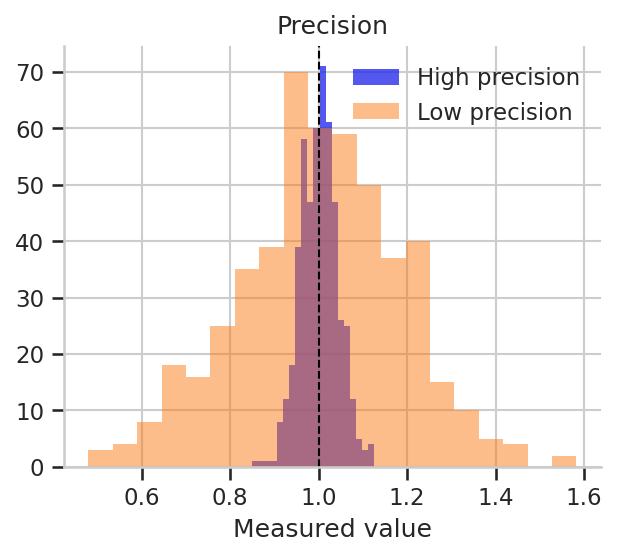

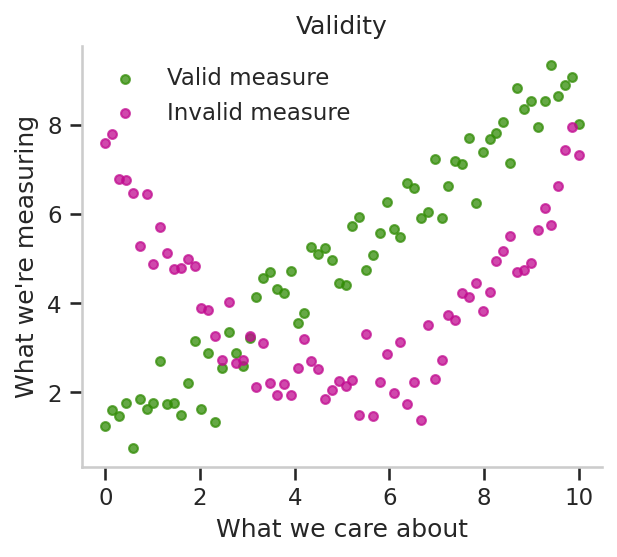

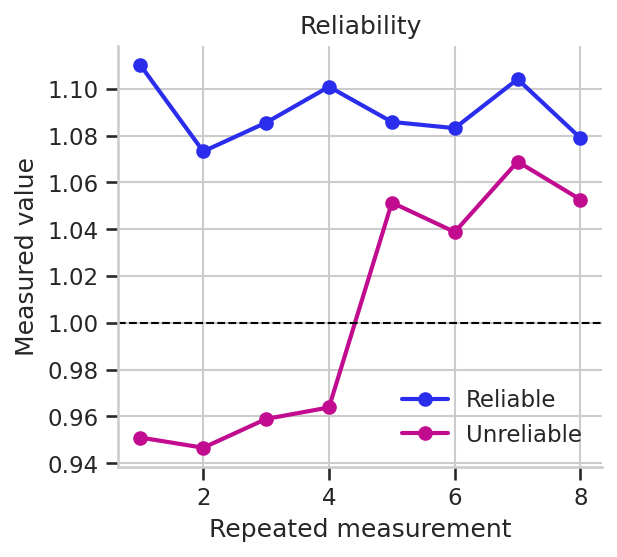

In [94]:
truth = 1.0
precise = rng.normal(truth, 0.04, size=500)
imprecise = rng.normal(truth, 0.18, size=500)
what_we_care_about = np.linspace(0, 10, 70)
valid_curve = 0.8 * what_we_care_about + 1.0
invalid_curve = 0.22 * (what_we_care_about - 5.0) ** 2 + 2.2
valid_measure = valid_curve + rng.normal(0, 0.6, size=what_we_care_about.size)
invalid_measure = invalid_curve + rng.normal(0, 0.6, size=what_we_care_about.size)
sessions = np.arange(1, 9)
reliable = truth + rng.normal(0.1, 0.02, size=sessions.size)
half = sessions.size // 2
unreliable = np.concatenate([
    truth + rng.normal(-0.05, 0.02, size=half),
    truth + rng.normal(+0.05, 0.02, size=sessions.size - half),
])

fig, ax = plt.subplots(figsize=(4, 3.6), constrained_layout=True)
ax.hist(precise, bins=20, alpha=0.8, color='C0', label='High precision')
ax.hist(imprecise, bins=20, alpha=0.5, color='C1', label='Low precision')
ax.axvline(truth, color='k', linestyle='--', linewidth=1)
ax.set_title('Precision')
ax.set_xlabel('Measured value')
ax.legend(frameon=False)

fig, ax = plt.subplots(figsize=(4, 3.6), constrained_layout=True)
ax.scatter(what_we_care_about, valid_measure, s=18, color='C2', alpha=0.75, label='Valid measure')
ax.scatter(what_we_care_about, invalid_measure, s=18, color='C3', alpha=0.75, label='Invalid measure')
ax.set_title('Validity')
ax.set_xlabel('What we care about')
ax.set_ylabel("What we're measuring")
ax.grid(False)
ax.legend(frameon=False)

fig, ax = plt.subplots(figsize=(4, 3.6), constrained_layout=True)
ax.plot(sessions, reliable, marker='o', linewidth=2, color='C0', label='Reliable')
ax.plot(sessions, unreliable, marker='o', linewidth=2, color='C3', label='Unreliable')
ax.axhline(truth, color='k', linestyle='--', linewidth=1)
ax.set_title('Reliability')
ax.set_xlabel('Repeated measurement')
ax.set_ylabel('Measured value')
ax.legend(frameon=False)


### Literature-backed examples

The lecture discusses literature-backed examples in this section.
The article figures stay in the slides rather than being embedded in the notebook.


<a id="section-15"></a>
## 1.5 Types of data
### How measurements are represented and analyzed


,Gender,Handedness,Age,Education,TIV_mm3,Normalized brain volume
0,Female,Right,74,High school,1344,0.743
1,Male,Right,39,College,1636,0.739


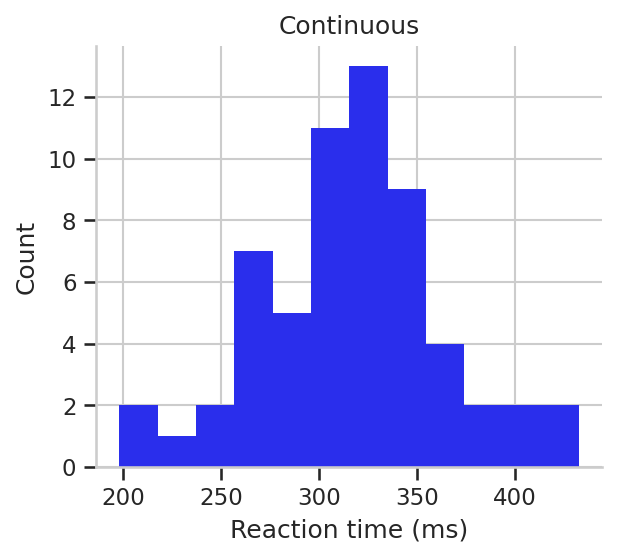

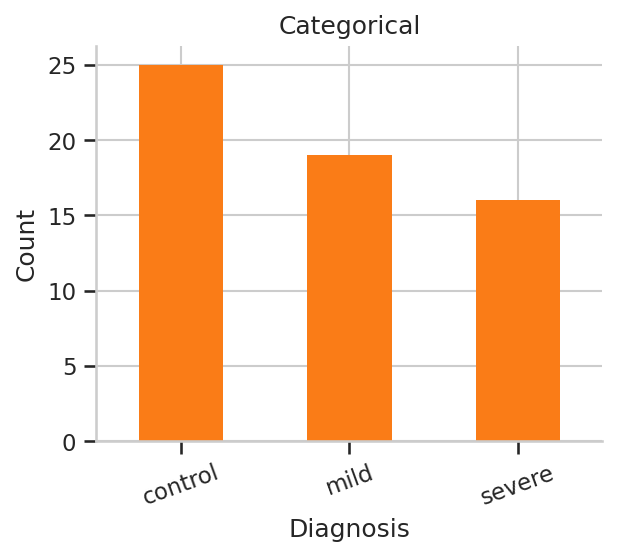

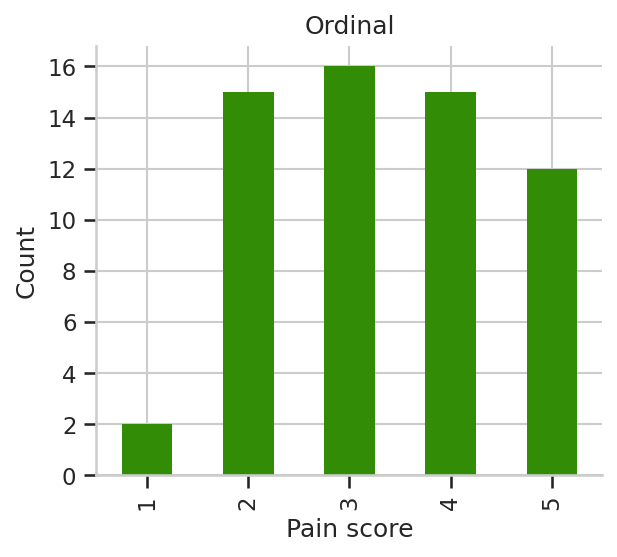

In [95]:
toy_data = pd.DataFrame({
    'reaction_time_ms': rng.normal(320, 45, size=60).round(0),
    'diagnosis': rng.choice(['control', 'mild', 'severe'], p=[0.45, 0.35, 0.20], size=60),
    'pain_score': rng.choice([1, 2, 3, 4, 5], p=[0.08, 0.18, 0.30, 0.28, 0.16], size=60),
})

fig, ax = plt.subplots(figsize=(4, 3.6), constrained_layout=True)
ax.hist(toy_data['reaction_time_ms'], bins=12, color='C0')
ax.set_title('Continuous')
ax.set_xlabel('Reaction time (ms)')
ax.set_ylabel('Count')

diagnosis_order = ['control', 'mild', 'severe']
fig, ax = plt.subplots(figsize=(4, 3.6), constrained_layout=True)
toy_data['diagnosis'].value_counts().reindex(diagnosis_order).plot.bar(ax=ax, color='C1')
ax.set_title('Categorical')
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=20)

fig, ax = plt.subplots(figsize=(4, 3.6), constrained_layout=True)
toy_data['pain_score'].value_counts().sort_index().plot.bar(ax=ax, color='C2')
ax.set_title('Ordinal')
ax.set_xlabel('Pain score')
ax.set_ylabel('Count')

mixed_example = pd.DataFrame([
    {
        'Gender': 'Female',
        'Handedness': 'Right',
        'Age': 74,
        'Education': 'High school',
        'TIV_mm3': 1344,
        'Normalized brain volume': 0.743,
    },
    {
        'Gender': 'Male',
        'Handedness': 'Right',
        'Age': 39,
        'Education': 'College',
        'TIV_mm3': 1636,
        'Normalized brain volume': 0.739,
    },
])
display(mixed_example)


<a id="section-16"></a>
## 1.6 Probability and uncertainty
### Quantifying uncertainty about unknown quantities

Slides 39-44 are mostly conceptual. The next cells reproduce the concrete figures worth keeping in the notebook.

Text(20, 0.78, 'End proportion = 0.532')

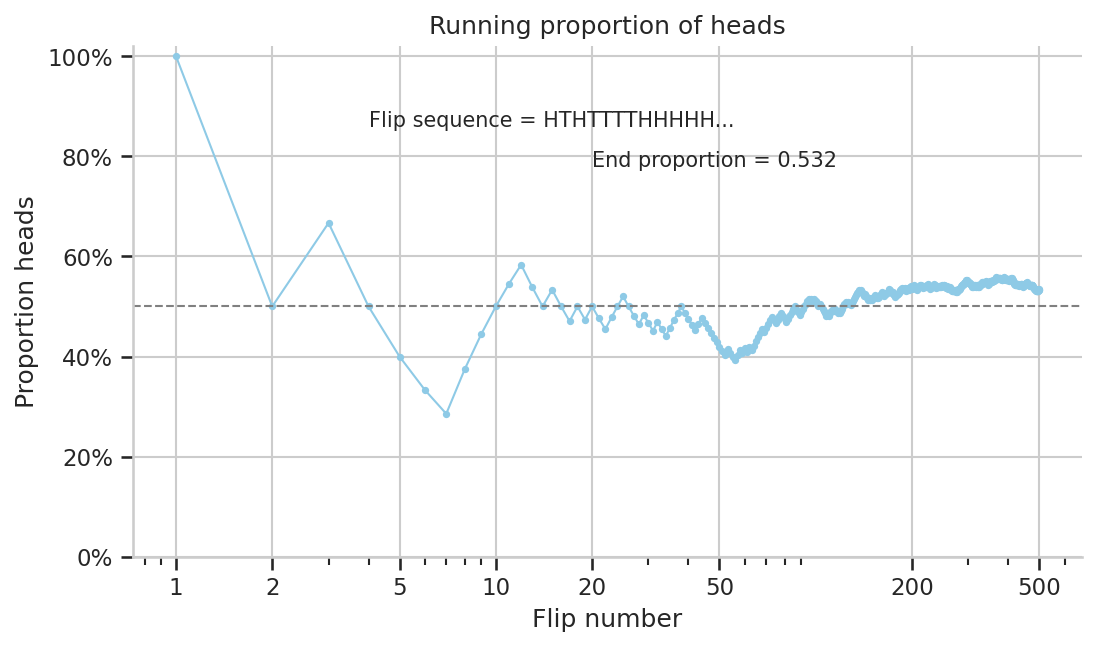

In [96]:
n_flips = 500
flips = rng.choice(['H', 'T'], size=n_flips)
heads = (flips == 'H').astype(int)
running_heads = heads.cumsum() / np.arange(1, n_flips + 1)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
x = np.arange(1, n_flips + 1)
ax.plot(x, running_heads, marker='o', markersize=2.5, linewidth=1.0, color='#8ecae6')
ax.axhline(0.5, linestyle='--', linewidth=1, color='0.5')
ax.set_xscale('log')
ax.set_xticks([1, 2, 5, 10, 20, 50, 200, 500])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 1.02)
ax.set_xlabel('Flip number')
ax.set_ylabel('Proportion heads')
ax.set_title('Running proportion of heads')
ax.text(4, 0.86, f"Flip sequence = {''.join(flips[:12])}...", fontsize=10)
ax.text(20, 0.78, f'End proportion = {running_heads[-1]:.3f}', fontsize=10)


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

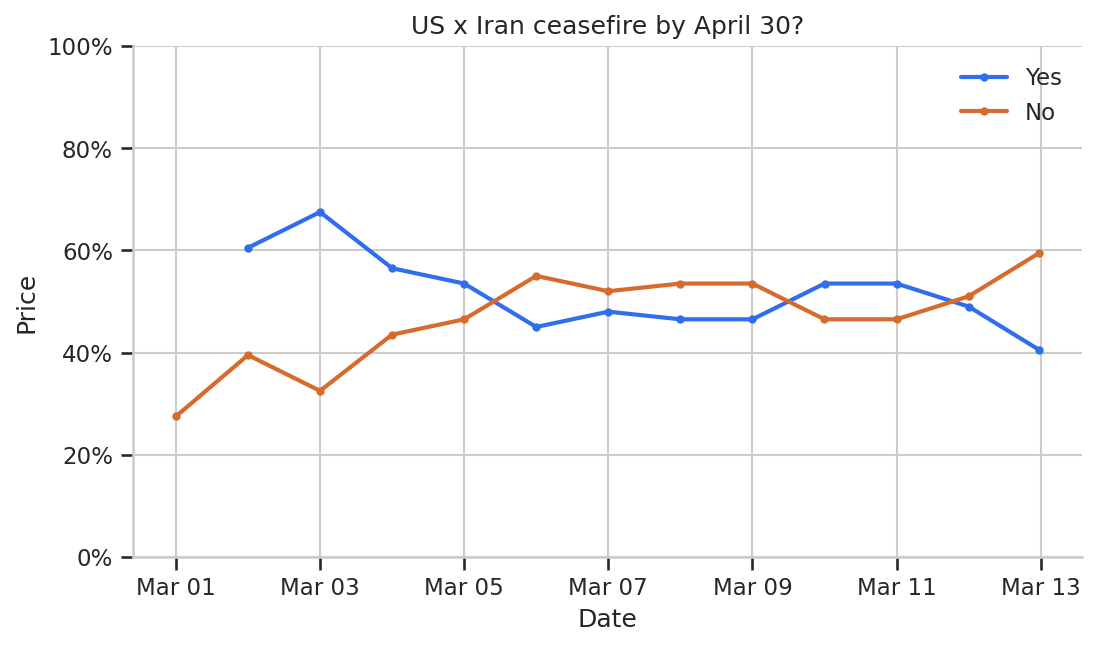

In [97]:
market_history = read_data_csv('polymarket_us-x-iran-ceasefire-by-april-30-194_2026-03-01_to_2026-03-12.csv', parse_dates=['timestamp_utc'])

fig, ax = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)
colors = {'Yes': '#2f6fed', 'No': '#d66b2d'}

for outcome in ['Yes', 'No']:
    outcome_history = market_history.loc[market_history['outcome'] == outcome].sort_values('timestamp_utc')
    ax.plot(
        outcome_history['timestamp_utc'],
        outcome_history['price'],
        linewidth=2,
        marker='o',
        markersize=3,
        color=colors[outcome],
        label=outcome,
    )

ax.set_title(market_history['question'].iloc[0])
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax.legend(frameon=False)
plt.setp(ax.get_xticklabels(), rotation=0, ha='center')

<a id="section-17"></a>
## 1.7 Probability distributions
### Parameterized probability distributions express multiple possibilities


Text(0, 0.5, 'Probability density')

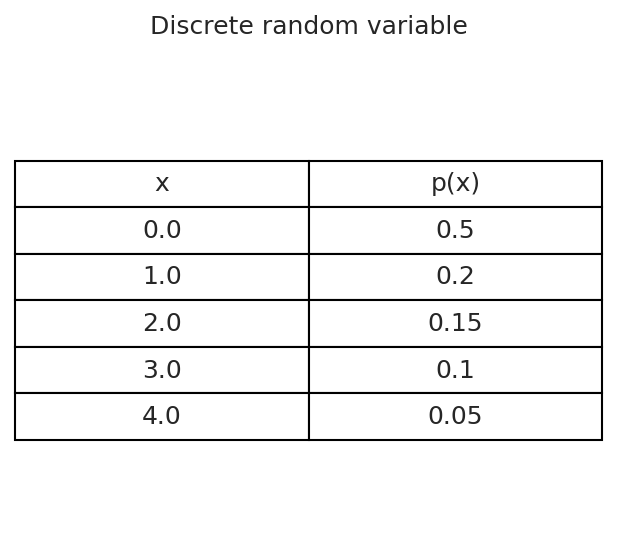

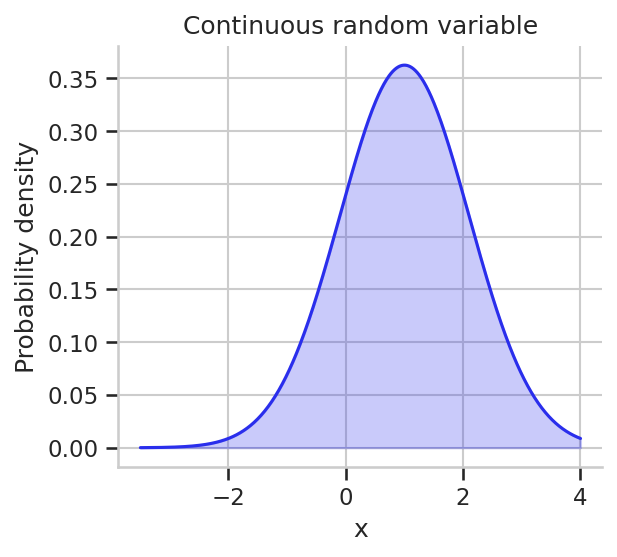

In [112]:
rv_table = pd.DataFrame({'x': [0, 1, 2, 3, 4], 'p(x)': [0.5, 0.2, 0.15, 0.1, 0.05]})
x = np.linspace(-3.5, 4, 500)
density = stats.norm.pdf(x, loc=1.0, scale=1.1)

fig, ax_table = plt.subplots(figsize=(4, 3.6), constrained_layout=True)
ax_table.axis('off')
table = ax_table.table(
    cellText=rv_table.values,
    colLabels=rv_table.columns,
    loc='center',
    cellLoc='center',
    colLoc='center',
)
table.scale(1.1, 1.6)
ax_table.set_title('Discrete random variable', pad=12)

fig, ax_pdf = plt.subplots(figsize=(4, 3.6), constrained_layout=True)
ax_pdf.plot(x, density, color='C0')
ax_pdf.fill_between(x, density, alpha=0.25, color='C0')
ax_pdf.set_title('Continuous random variable')
ax_pdf.set_xlabel('x')
ax_pdf.set_ylabel('Probability density')


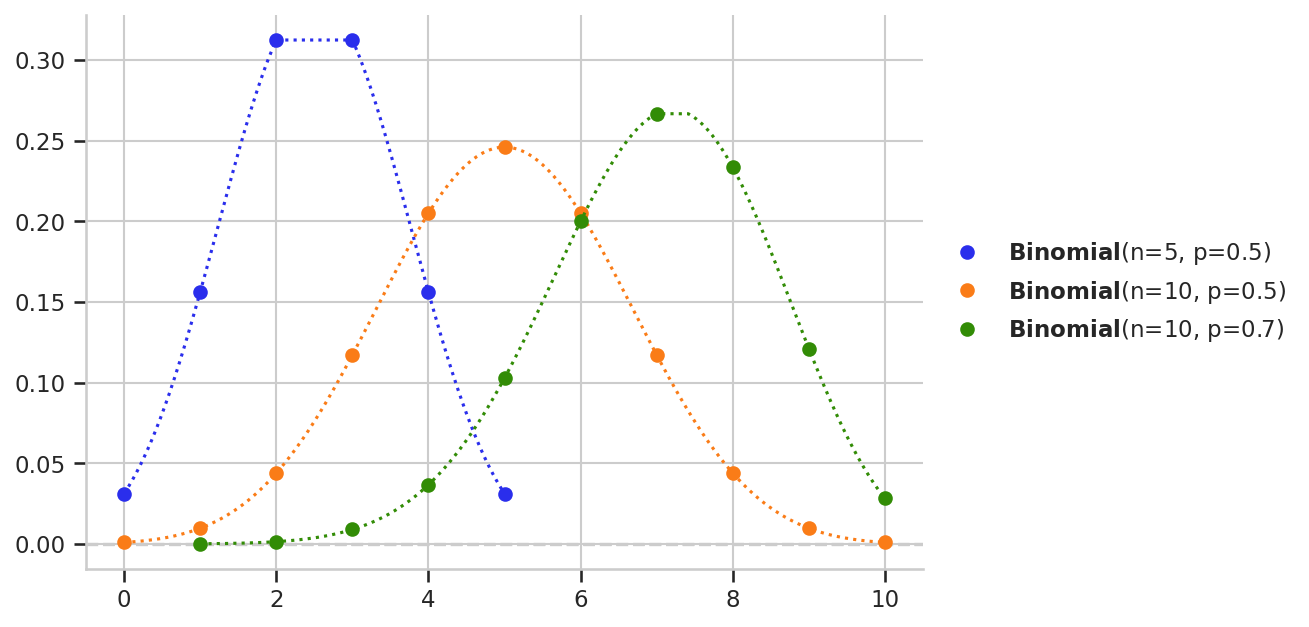

In [99]:
ns = [5, 10, 10]
ps = [0.5, 0.5, 0.7]
for n, p in zip(ns, ps):
    pz.Binomial(n, p).plot_pdf()


In [100]:
from IPython import get_ipython

shell_name = type(get_ipython()).__name__ if get_ipython() is not None else ''
has_widgets = importlib.util.find_spec('ipywidgets') is not None

if shell_name == 'ZMQInteractiveShell' and has_widgets:
    pz.BetaBinomial(alpha=10, beta=10, n=5).plot_interactive(pointinterval=False)
else:
    print('Interactive widgets unavailable; showing a static PMF instead.')
    pz.BetaBinomial(alpha=10, beta=10, n=5).plot_pdf()


<Axes: >

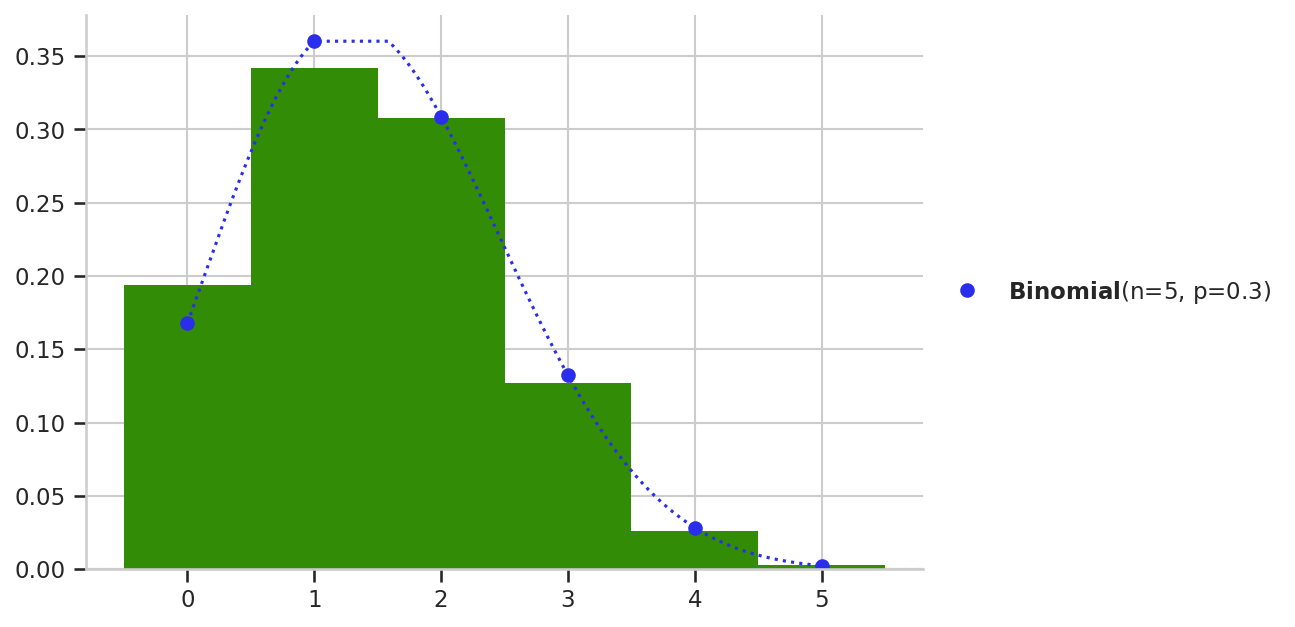

In [101]:
plt.hist(
    pz.Binomial(p=0.3, n=5).rvs(1000),
    bins=[0, 1, 2, 3, 4, 5, 6],
    density=True,
    align='left',
    color='C2',
)
pz.Binomial(p=0.3, n=5).plot_pdf()


[None, None, None]

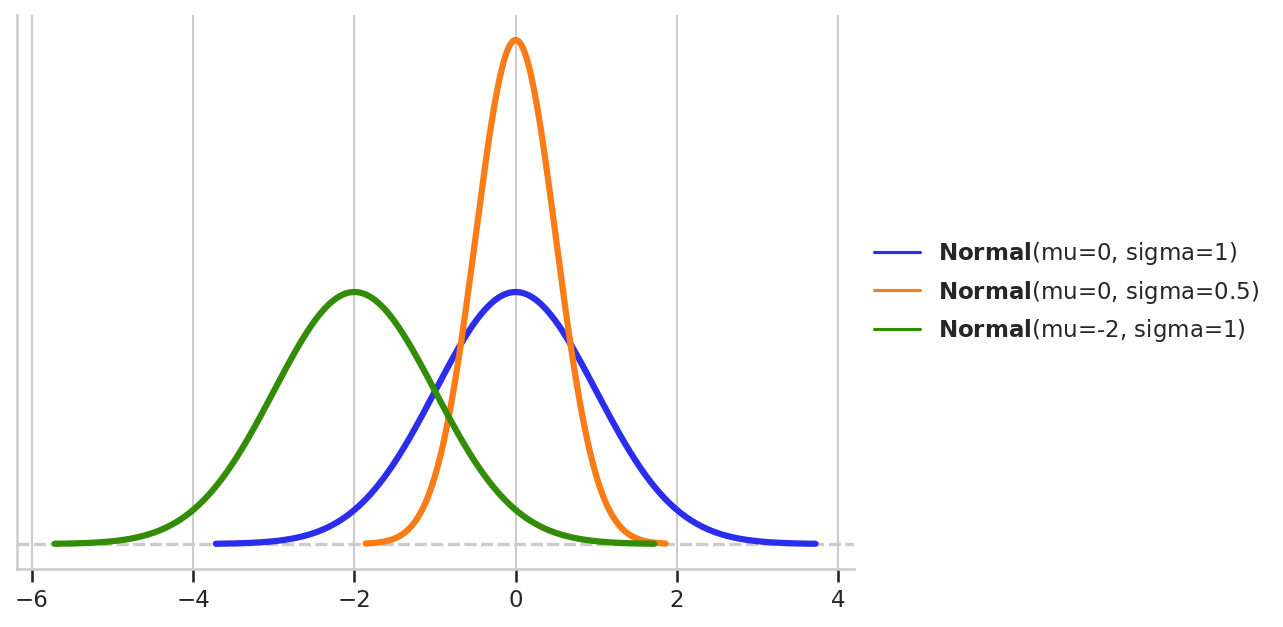

In [102]:
mus = [0.0, 0.0, -2.0]
sigmas = [1, 0.5, 1]
for mu, sigma in zip(mus, sigmas):
    ax = pz.Normal(mu, sigma).plot_pdf()

[line.set_linewidth(3.0) for line in ax.get_lines()[1::2]]


np.float64(0.4772498680518208)

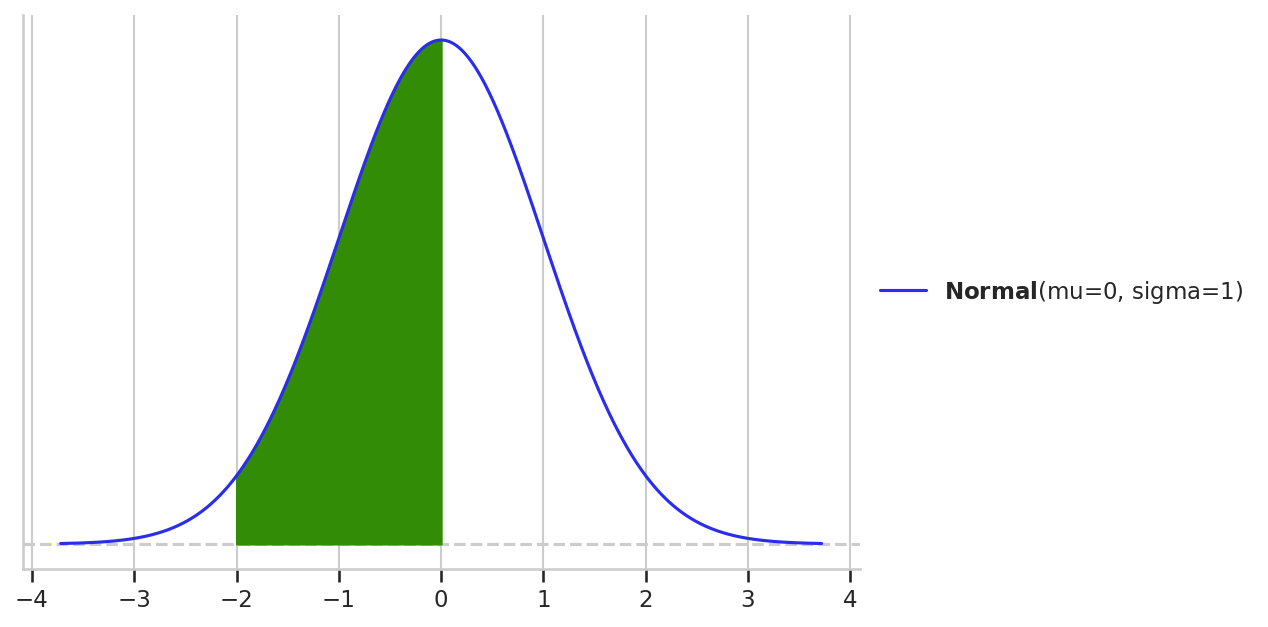

In [103]:
dist = pz.Normal(0, 1)
ax = dist.plot_pdf()
x_s = np.linspace(-2, 0)
ax.fill_between(x_s, dist.pdf(x_s), color='C2')
dist.cdf(0) - dist.cdf(-2)


<Axes: >

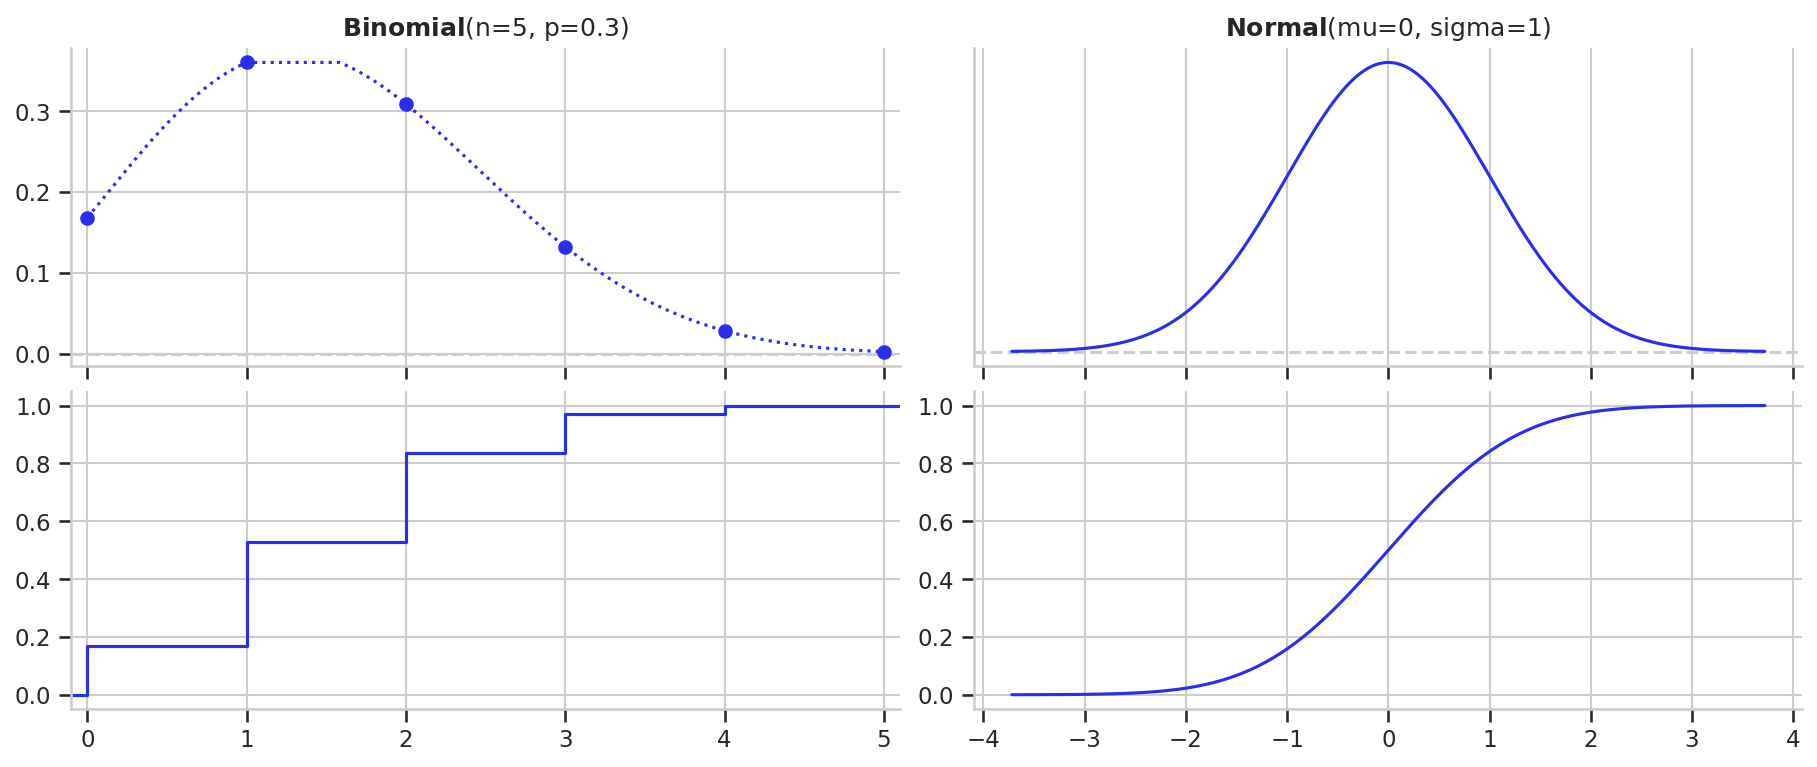

In [104]:
_, ax = plt.subplots(2, 2, figsize=(12, 5), sharex='col')
pz.Binomial(p=0.3, n=5).plot_pdf(ax=ax[0, 0], legend='title')
pz.Binomial(p=0.3, n=5).plot_cdf(ax=ax[1, 0], legend=None)
pz.Normal(0, 1).plot_pdf(ax=ax[0, 1], legend='title')
pz.Normal(0, 1).plot_cdf(ax=ax[1, 1], legend=None)


<a id="section-18"></a>
## 1.8 Parameters and describing distributions
### Summarizing the world

Slides 58-59 are conceptual lead-ins. The cells below reproduce the concrete examples from the later slides in the section.


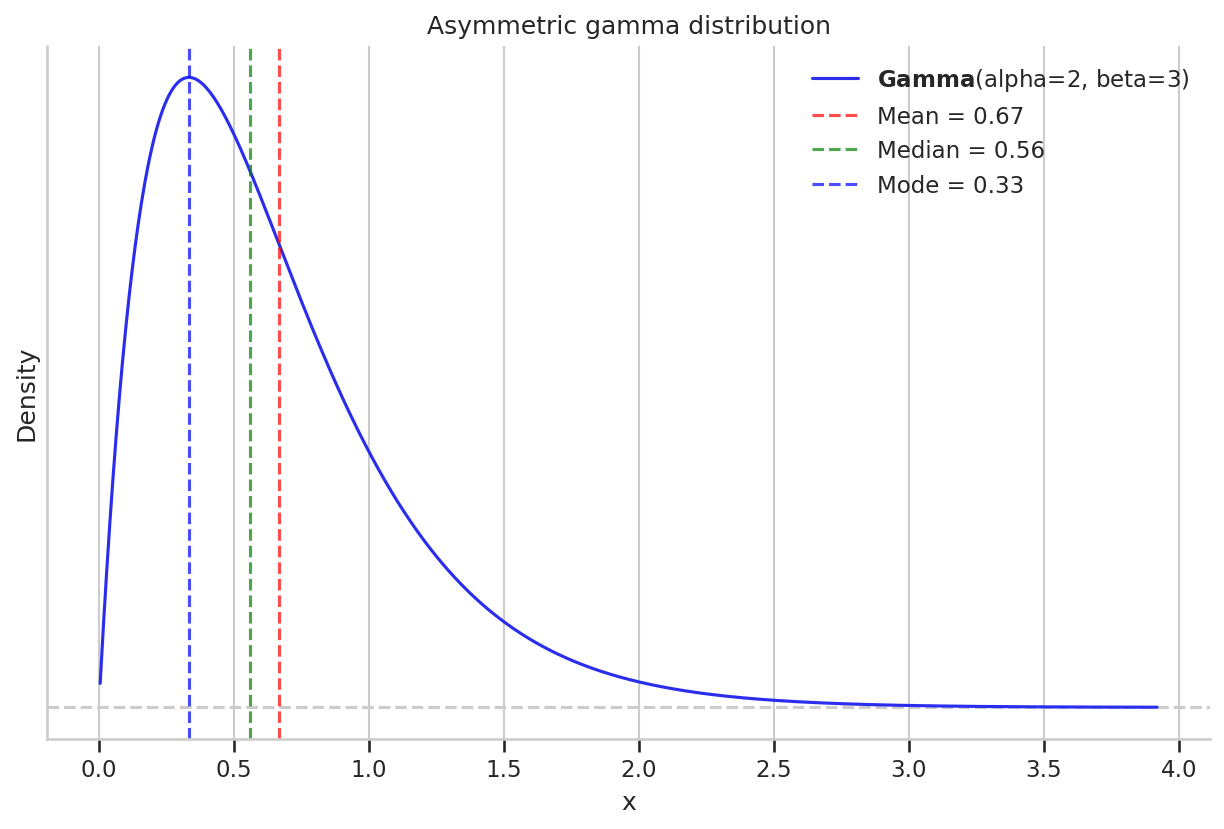

In [105]:
alpha = 2
beta = 3
gamma_dist = pz.Gamma(alpha=alpha, beta=beta)

mean = gamma_dist.mean()
median = gamma_dist.median()
mode = gamma_dist.mode()

fig, ax = plt.subplots(figsize=(10, 6))
gamma_dist.plot_pdf(ax=ax)

x_range = np.linspace(0, 4, 1000)
ax.axvline(mean, color='red', linestyle='--', alpha=0.7, label=f'Mean = {mean:.2f}')
ax.axvline(median, color='green', linestyle='--', alpha=0.7, label=f'Median = {median:.2f}')
ax.axvline(mode, color='blue', linestyle='--', alpha=0.7, label=f'Mode = {mode:.2f}')
ax.set_title('Asymmetric gamma distribution')
ax.set_xlabel('x')
ax.set_ylabel('Density')
ax.legend(frameon=False)


Text(0, 0.5, 'Count')

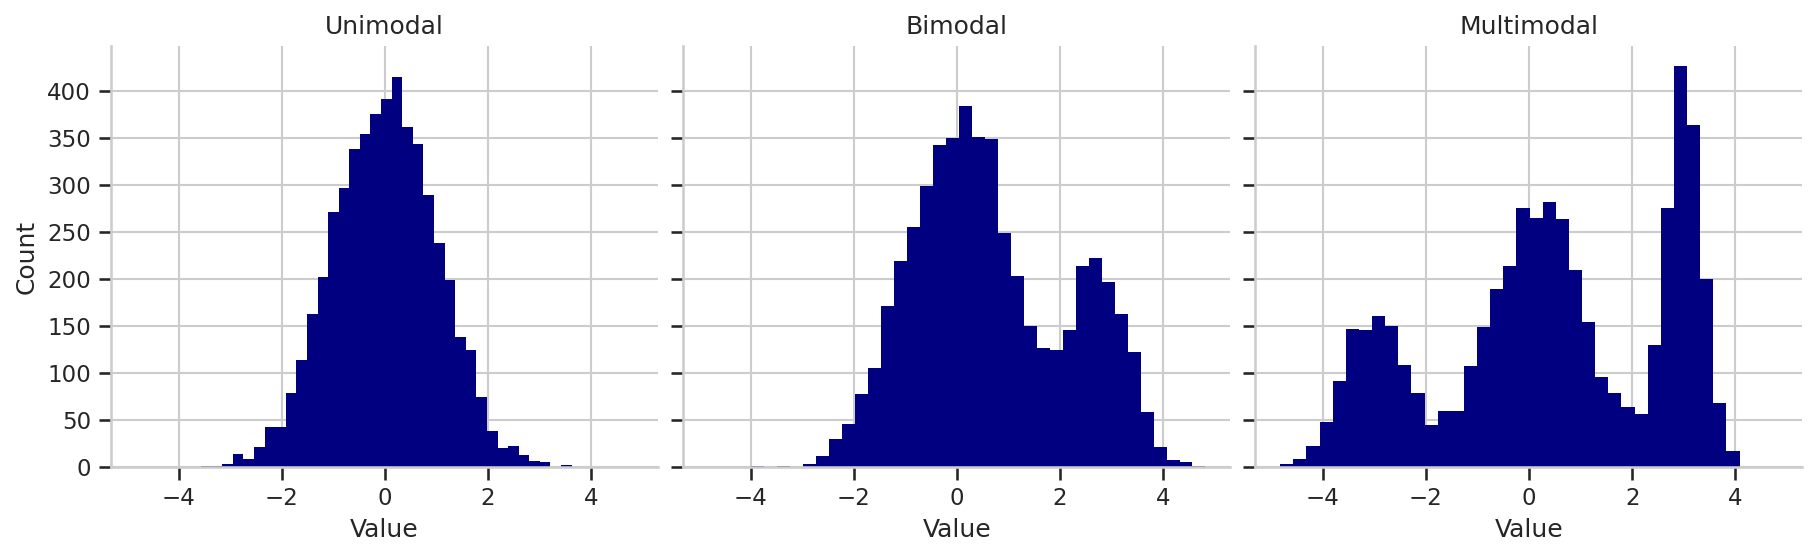

In [106]:
unimodal = rng.normal(0, 1.0, size=5000)
bimodal = np.concatenate([rng.normal(0, 1.0, size=3800), rng.normal(2.8, 0.55, size=1200)])
multimodal = np.concatenate([
    rng.normal(-3.0, 0.6, size=1000),
    rng.normal(0.2, 0.9, size=2500),
    rng.normal(3.0, 0.35, size=1500),
])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, sharey=True, constrained_layout=True)
datasets = [('Unimodal', unimodal), ('Bimodal', bimodal), ('Multimodal', multimodal)]

for ax, (title, values) in zip(axes, datasets):
    ax.hist(values, bins=35, color='navy')
    ax.set_title(title)
    ax.set_xlabel('Value')
axes[0].set_ylabel('Count')


Text(0, 0.5, 'Count')

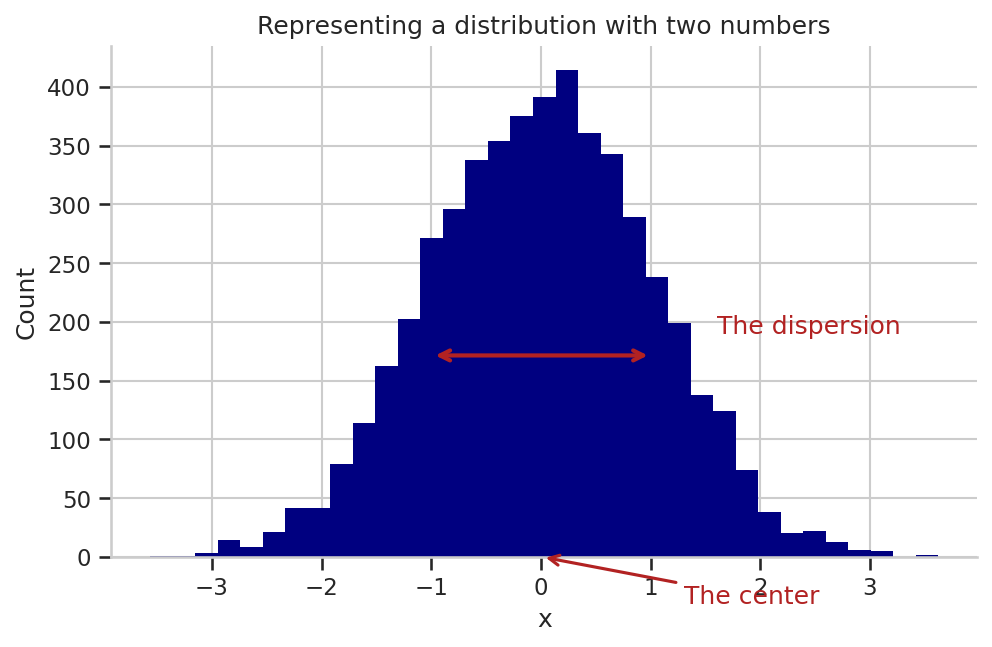

In [107]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
counts, bins, _ = ax.hist(unimodal, bins=35, color='navy')
center = np.mean(unimodal)
spread = np.std(unimodal, ddof=1)
peak_y = counts.max() * 0.92

ax.annotate('The center', xy=(center, 0), xytext=(center + 1.3, -40), arrowprops={'arrowstyle': '->', 'color': 'firebrick', 'lw': 1.5}, color='firebrick')
ax.annotate('', xy=(center - spread, peak_y * 0.45), xytext=(center + spread, peak_y * 0.45), arrowprops={'arrowstyle': '<->', 'color': 'firebrick', 'lw': 2})
ax.text(center + 1.6, peak_y * 0.5, 'The dispersion', color='firebrick')
ax.set_title('Representing a distribution with two numbers')
ax.set_xlabel('x')
ax.set_ylabel('Count')


In [108]:
center = np.mean(unimodal)
variance = np.var(unimodal, ddof=1)
std = np.std(unimodal, ddof=1)
mad = np.mean(np.abs(unimodal - center))
q1, q3 = np.quantile(unimodal, [0.25, 0.75])
iqr = q3 - q1

pd.Series({
    'mean': center,
    'variance': variance,
    'standard deviation': std,
    'absolute deviation (MAD)': mad,
    'inter-quartile interval': iqr,
}).to_frame('value').style.format('{:.3f}')


,value
mean,0.006
variance,1.013
standard deviation,1.006
absolute deviation (MAD),0.808
inter-quartile interval,1.386


In [113]:
# Center each comparison at 0 with variance 1 so shape differences are easier to see.
def standardized_skew_normal(alpha):
    delta = alpha / np.sqrt(1 + alpha**2)
    sigma = 1 / np.sqrt(1 - 2 * delta**2 / np.pi)
    mu = -sigma * delta * np.sqrt(2 / np.pi)
    return pz.SkewNormal(mu, sigma, alpha)


def standardized_beta_scaled(shape):
    limit = np.sqrt(2 * shape + 1)
    return pz.BetaScaled(alpha=shape, beta=shape, lower=-limit, upper=limit)


def standardized_student_t(nu):
    scale = np.sqrt((nu - 2) / nu)
    return pz.StudentT(nu, 0, scale)


Text(0, 0.5, 'Density')

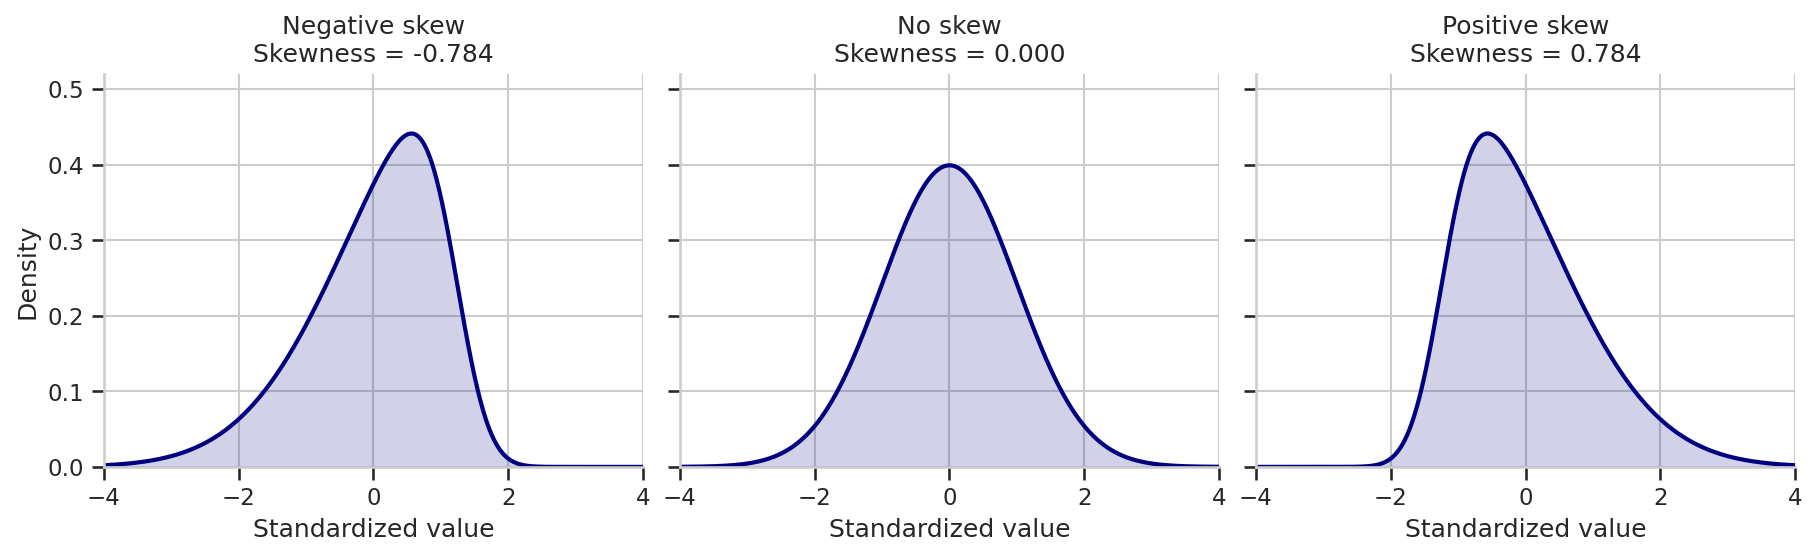

In [114]:
x = np.linspace(-4, 4, 800)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, sharey=True, constrained_layout=True)
skew_examples = [
    ('Negative skew', standardized_skew_normal(-4)),
    ('No skew', pz.Normal(0, 1)),
    ('Positive skew', standardized_skew_normal(4)),
]

for ax, (title, dist) in zip(axes, skew_examples):
    y = dist.pdf(x)
    ax.plot(x, y, color='navy', linewidth=2)
    ax.fill_between(x, y, color='navy', alpha=0.18)
    ax.set_title(f"{title}\nSkewness = {dist.skewness():.3f}")
    ax.set_xlabel('Standardized value')
    ax.set_xlim(-4, 4)
    ax.set_ylim(0, 0.52)
axes[0].set_ylabel('Density')


d:\Repositories\StatisticalComputationAndAnalysis\.pixi\envs\default\Lib\site-packages\pytensor\tensor\xlogx.py:47: RuntimeWarning: invalid value encountered in log
  return x * np.log(y)


Text(0, 0.5, 'Density')

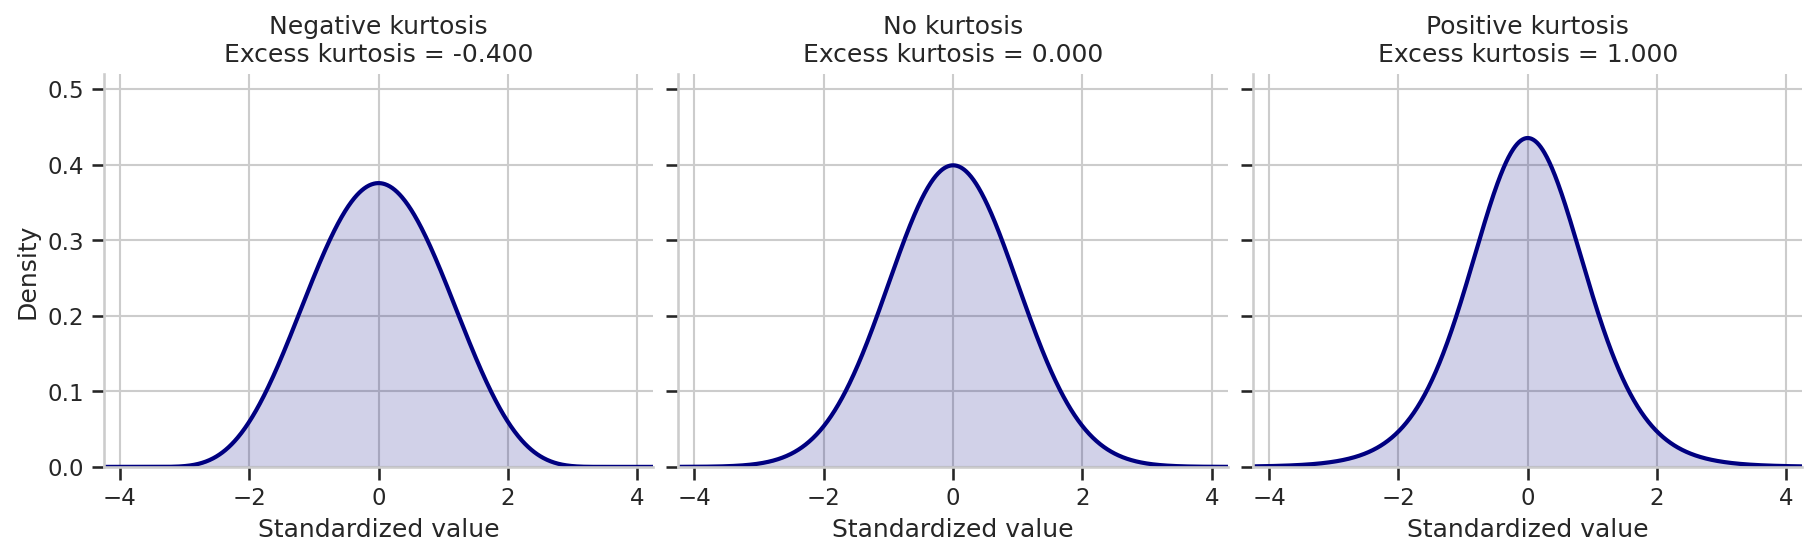

In [115]:
x = np.linspace(-4.25, 4.25, 900)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharex=True, sharey=True, constrained_layout=True)
kurtosis_examples = [
    ('Negative kurtosis', standardized_beta_scaled(6)),
    ('No kurtosis', pz.Normal(0, 1)),
    ('Positive kurtosis', standardized_student_t(10)),
]

for ax, (title, dist) in zip(axes, kurtosis_examples):
    y = dist.pdf(x)
    ax.plot(x, y, color='navy', linewidth=2)
    ax.fill_between(x, y, color='navy', alpha=0.18)
    ax.set_title(f"{title}\nExcess kurtosis = {dist.kurtosis():.3f}")
    ax.set_xlabel('Standardized value')
    ax.set_xlim(-4.25, 4.25)
    ax.set_ylim(0, 0.52)
axes[0].set_ylabel('Density')


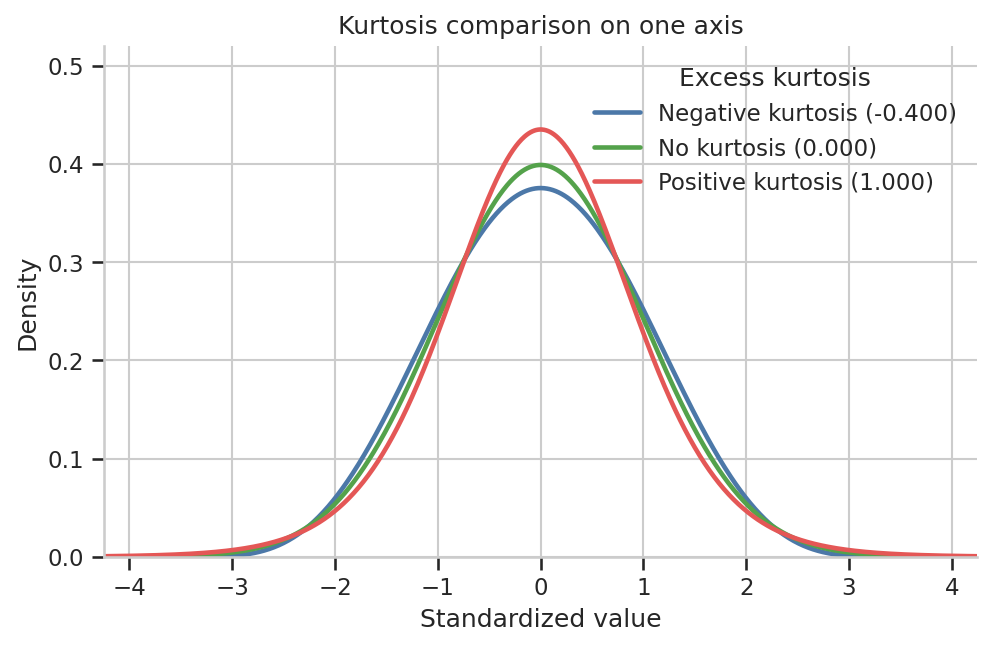

In [116]:
x = np.linspace(-4.25, 4.25, 900)
kurtosis_overlay_examples = [
    ('Negative kurtosis', standardized_beta_scaled(6), '#4c78a8'),
    ('No kurtosis', pz.Normal(0, 1), '#54a24b'),
    ('Positive kurtosis', standardized_student_t(10), '#e45756'),
]

fig, ax = plt.subplots(figsize=(6.5, 4.2), constrained_layout=True)

for label, dist, color in kurtosis_overlay_examples:
    y = dist.pdf(x)
    ax.plot(
        x,
        y,
        color=color,
        linewidth=2.2,
        label=f"{label} ({dist.kurtosis():.3f})",
    )

ax.set_title('Kurtosis comparison on one axis')
ax.set_xlabel('Standardized value')
ax.set_ylabel('Density')
ax.set_xlim(-4.25, 4.25)
ax.set_ylim(0, 0.52)
ax.legend(title='Excess kurtosis', frameon=False)


<Axes: title={'center': '$\\bf{StudentT}$(nu=3, mu=0, sigma=1)\nμ=0, σ=1.73, γ=nan, κ=inf'}>

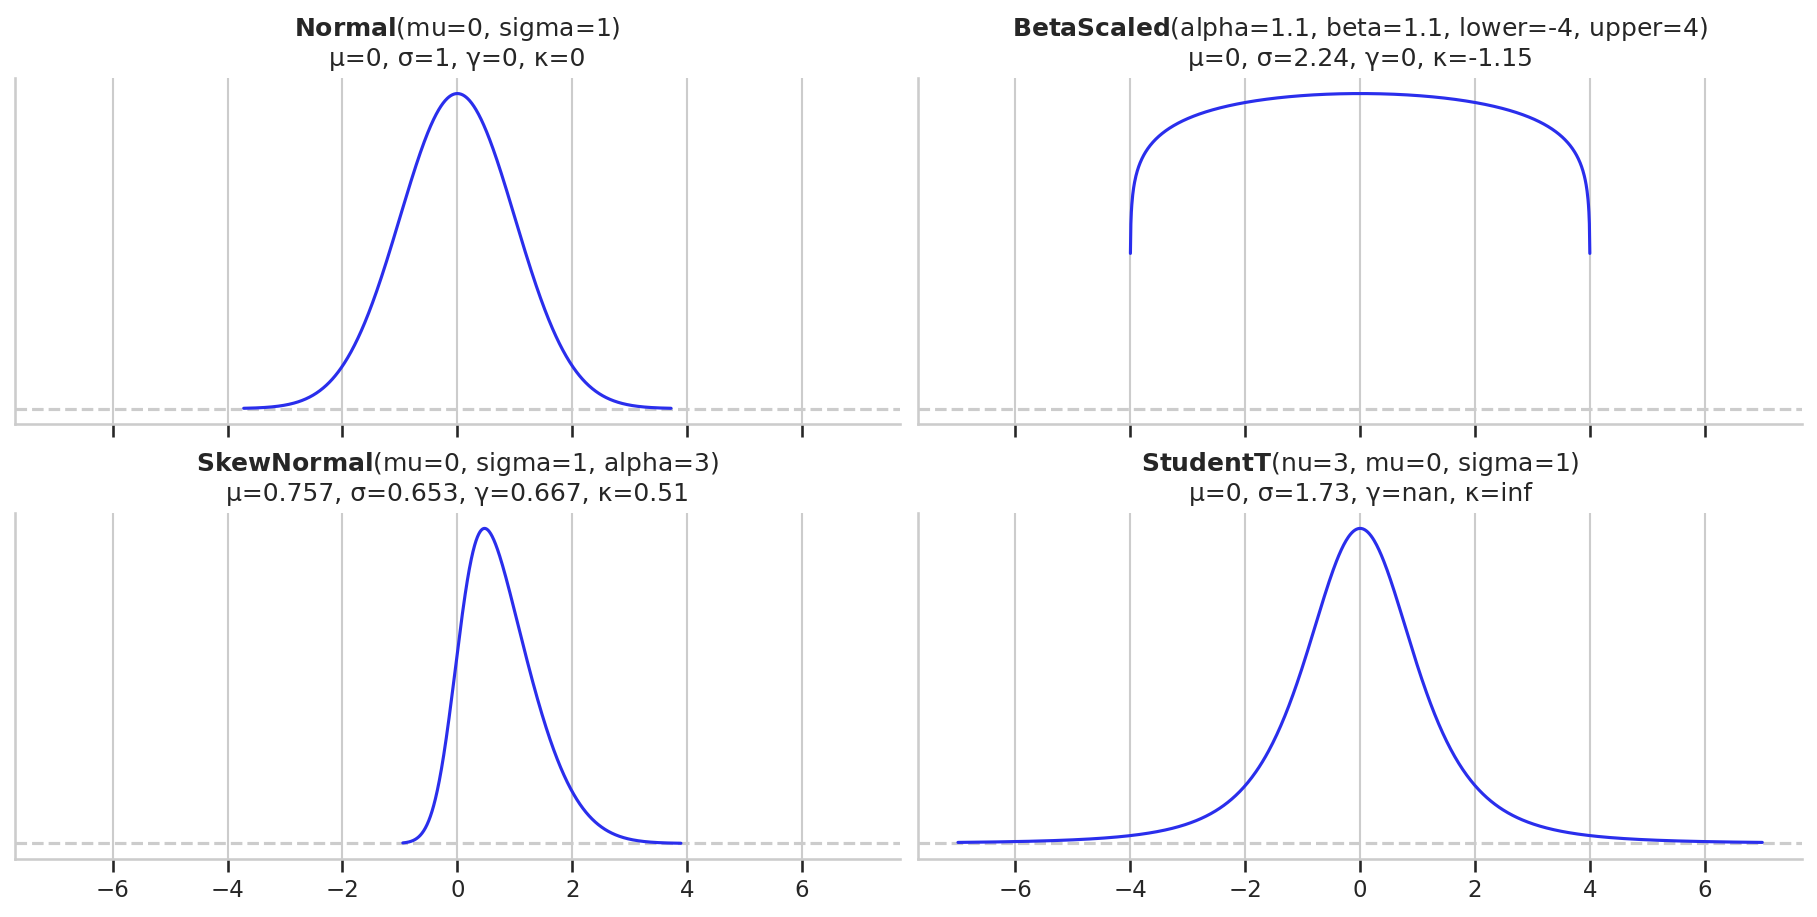

In [111]:
_, ax = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
pz.Normal(0, 1).plot_pdf(ax=ax[0, 0], moments=['m', 'd', 's', 'k'], legend='title')
pz.BetaScaled(1.1, 1.1, -4, 4).plot_pdf(ax=ax[0, 1], moments=['m', 'd', 's', 'k'], legend='title')
pz.SkewNormal(0, 1, 3).plot_pdf(ax=ax[1, 0], moments=['m', 'd', 's', 'k'], legend='title')
pz.StudentT(3, 0, 1).plot_pdf(ax=ax[1, 1], moments=['m', 'd', 's', 'k'], legend='title', support=(-7, 7))


<a id="section-19"></a>
## 1.9 About this course
### How we will learn statistical modeling

Slides 69-73 are course logistics and resources, so there is no notebook computation here.
